Si tenemos un sistemas lineal $\dot z = Az$, la solución $z^*=0$ siempre sera solucion de equilibrio

Proponemos (ansatz):

$$
x(t) = c e^{\lambda t},
$$

solución que proponemos.

Entonces,

$$
\dot{x}(t) = \lambda c e^{\lambda t}.
$$

Por tanto,

$$
\lambda c e^{\lambda t} = A(c e^{\lambda t})
\quad  \quad
\lambda c = A c.
$$

Por lo que $\lambda$ es un **valor propio** (*eigenvalor*)
y $c$ es un **vector propio** (*eigenvector*).

En particular, si A es una matriz de 2x2,
La solución general será

$$
x(t) = a_1 c_1 e^{\lambda_1 t} + a_2 c_2 e^{\lambda_2 t},
$$

con

$$
v = x(0) = a_1 c_1 + a_2 c_2.
$$

Y por el polinomio característico, sabemos que

$$
\lambda^2 - \lambda \operatorname{tr}(A) + \det(A) = 0.
$$

Entonces,

$$
\lambda_{1,2}
= \frac{\operatorname{tr}(A) \pm \sqrt{(\operatorname{tr}(A))^2 - 4\det(A)}}{2}.
$$

Por lo que existen 3 casos: $\quad\det(A) < 0$, $\quad\det(A) = 0\quad$ y $\quad\det(A) > 0$.

---

### $\leadsto$ Si $\det(A) < 0$.
$$
(\operatorname{tr}(A))^2 - 4\det(A)>0\quad\text{por lo que}\quad \lambda _1,\lambda _2\in\mathbb{R}\quad\text{y tienen signos contrarios}
$$

Esto nos dice que nuestro sistema tiene 2 variable, una estable y una inestable

En este caso, tenemos que $z^*=0$ es un punto silla


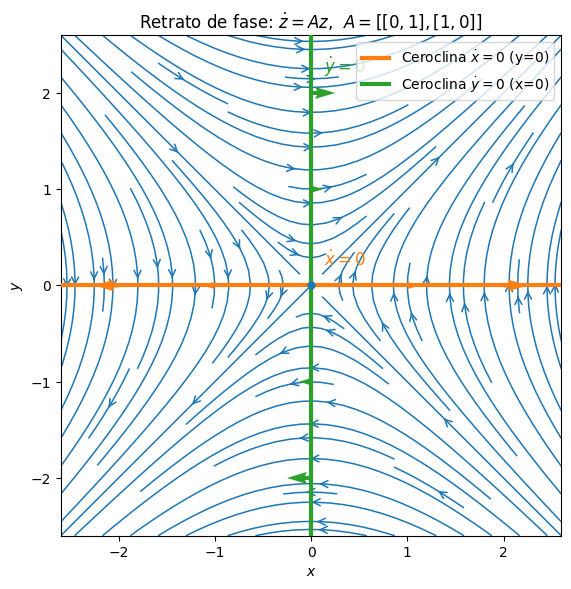

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Sistema: z' = A z,  A = [[0,1],[1,0]]  =>  x' = y, y' = x
def f(x, y):
    return y, x

# ----- Parámetros de la figura -----
L = 2.6
dens = 1.25
arrowsz = 1.25

# ----- Campo vectorial (para streamplot) -----
x = np.linspace(-L, L, 300)
y = np.linspace(-L, L, 300)
X, Y = np.meshgrid(x, y)
U, V = f(X, Y)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.streamplot(
    x, y, U, V,
    density=dens,
    linewidth=1.1,
    arrowsize=arrowsz,
    arrowstyle='->',
    color='tab:blue',
    zorder=1
)

# ----- "Ejes" x=0 y y=0 (en negro) -----
ax.axhline(0, color='k', lw=1, zorder=0)
ax.axvline(0, color='k', lw=1, zorder=0)

# ----- Cero-clinas -----
# xdot = 0  <=>  y = 0   (horizontal)
zerocline_xdot, = ax.plot([-L, L], [0, 0], color='tab:orange', lw=3, zorder=3)
# ydot = 0  <=>  x = 0   (vertical)
zerocline_ydot, = ax.plot([0, 0], [-L, L], color='tab:green', lw=3, zorder=3)

# Flechas sobre ceroclinas (opcional, para estilo)
xs = np.array([-2.0, -1.0, 1.0, 2.0])
ax.quiver(xs, 0*xs, xs, 0*xs, angles='xy', scale_units='xy', scale=8,
          width=0.008, color='tab:orange', zorder=4)

ys = np.array([-2.0, -1.0, 1.0, 2.0])
ax.quiver(0*ys, ys, ys, 0*ys, angles='xy', scale_units='xy', scale=8,
          width=0.008, color='tab:green', zorder=4)

# Punto en el origen
ax.plot(0, 0, 'o', color='tab:blue', ms=5, zorder=5)

# ----- Etiquetas de las ceroclinas (texto en el plano) -----
ax.text(0.05*L, 0.08*L, r'$\dot{x}=0$', color='tab:orange', fontsize=12)
ax.text(0.05*L, 0.85*L, r'$\dot{y}=0$', color='tab:green', fontsize=12)

# ----- Leyenda -----
handles = [
    Line2D([0], [0], color='tab:orange', lw=3, label=r'Ceroclina $\dot{x}=0$ (y=0)'),
    Line2D([0], [0], color='tab:green',  lw=3, label=r'Ceroclina $\dot{y}=0$ (x=0)'),
]
ax.legend(handles=handles, loc='upper right', frameon=True)

# ----- Formato -----
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title(r"Retrato de fase: $\dot{z}=Az$,  $A=[[0,1],[1,0]]$")

plt.show()


---

### $\leadsto$ Si $\det(A) = 0$

$$\text{Como}\quad
\lambda_{1,2}
= \frac{\operatorname{tr}(A) \pm \sqrt{(\operatorname{tr}(A))^2 - 4\det(A)}}{2}
\Rightarrow \lambda _1=0\quad y\quad\lambda _2=\operatorname{tr}(A)
$$

y esto nos dice que nuestro sistema solo tendria una variable estable o inestable


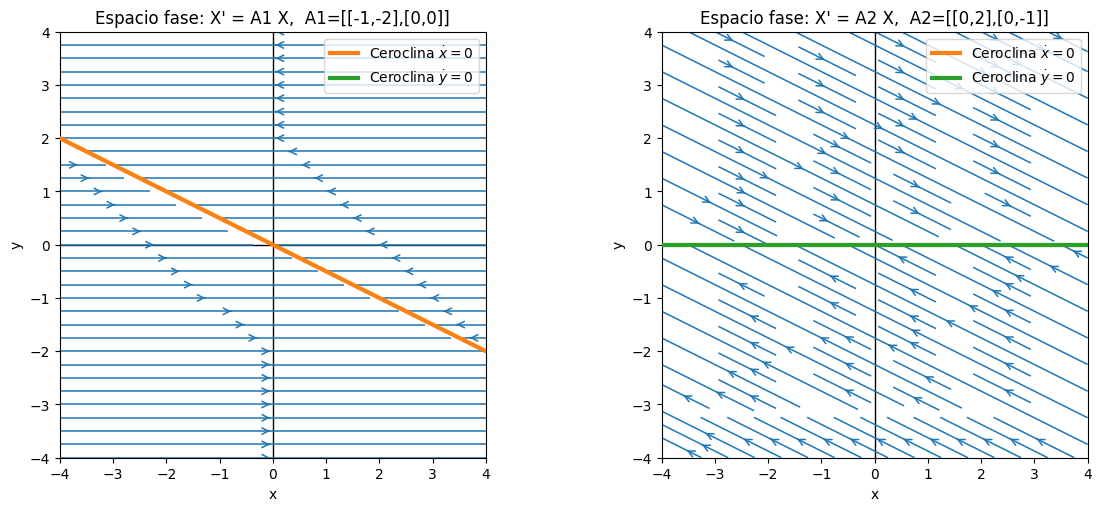

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_phase(ax, A, title, L=4, dens=1.1):
    # mallado
    x = np.linspace(-L, L, 300)
    y = np.linspace(-L, L, 300)
    X, Y = np.meshgrid(x, y)

    # campo: [x'; y'] = A [x; y]
    U = A[0,0]*X + A[0,1]*Y
    V = A[1,0]*X + A[1,1]*Y

    # retrato de fase
    ax.streamplot(x, y, U, V, density=dens, linewidth=1.1,
                  arrowsize=1.15, arrowstyle='->', color='tab:blue', zorder=1)

    # ejes cartesianos
    ax.axhline(0, color='k', lw=1, zorder=0)
    ax.axvline(0, color='k', lw=1, zorder=0)

    # --- ceroclinas ---
    # xdot = 0  => a11 x + a12 y = 0
    # ydot = 0  => a21 x + a22 y = 0
    a11, a12 = A[0,0], A[0,1]
    a21, a22 = A[1,0], A[1,1]

    xx = np.linspace(-L, L, 400)

    # Ceroclina xdot=0 (naranja)
    if abs(a12) > 1e-12:
        yy = -(a11/a12) * xx
        ax.plot(xx, yy, color='tab:orange', lw=3, zorder=3)
    else:
        # a12=0 -> a11 x = 0
        if abs(a11) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:orange', lw=3, zorder=3)

    # Ceroclina ydot=0 (verde)
    if abs(a22) > 1e-12:
        yy = -(a21/a22) * xx
        ax.plot(xx, yy, color='tab:green', lw=3, zorder=3)
    else:
        # a22=0 -> a21 x = 0
        if abs(a21) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:green', lw=3, zorder=3)

    # leyenda (misma en cada subplot)
    handles = [
        Line2D([0],[0], color='tab:orange', lw=3, label=r'Ceroclina $\dot{x}=0$'),
        Line2D([0],[0], color='tab:green',  lw=3, label=r'Ceroclina $\dot{y}=0$')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=True)

    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)

# ---- Matrices ----
A1 = np.array([[-1, -2],
               [ 0,  0]], dtype=float)

A2 = np.array([[ 0,  2],
               [ 0, -1]], dtype=float)

# ---- Figura con 2 imágenes ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_phase(axes[0], A1, "Espacio fase: X' = A1 X,  A1=[[-1,-2],[0,0]]", L=4, dens=1.1)
plot_phase(axes[1], A2, "Espacio fase: X' = A2 X,  A2=[[0,2],[0,-1]]",  L=4, dens=1.1)

plt.show()


### $\leadsto$ Si $\det(A) > 0$
Este caso tiene 3 subcasos, pues hay que considerar el discriminante de los valores propios, es decir:

$$\text{Como}\quad
\lambda_{1,2}
= \frac{\operatorname{tr}(A) \pm \sqrt{(\operatorname{tr}(A))^2 - 4\det(A)}}{2}.
$$

ahora hay que ver cuando ocurre que $(\operatorname{tr}(A))^2 - 4\det(A)>0,\quad(\operatorname{tr}(A))^2 - 4\det(A) = 0\quad(\operatorname{tr}(A))^2 - 4\det(A)$ por lo que:

### $$\hookrightarrow \text{Si}\quad \det(A) > 0\quad y \quad (\operatorname{tr}(A))^2 - 4\det(A)>0$$
 
Esto nos diria que $\lambda _1,\lambda _2\in\mathbb{R}$ y tienen el mismo signo

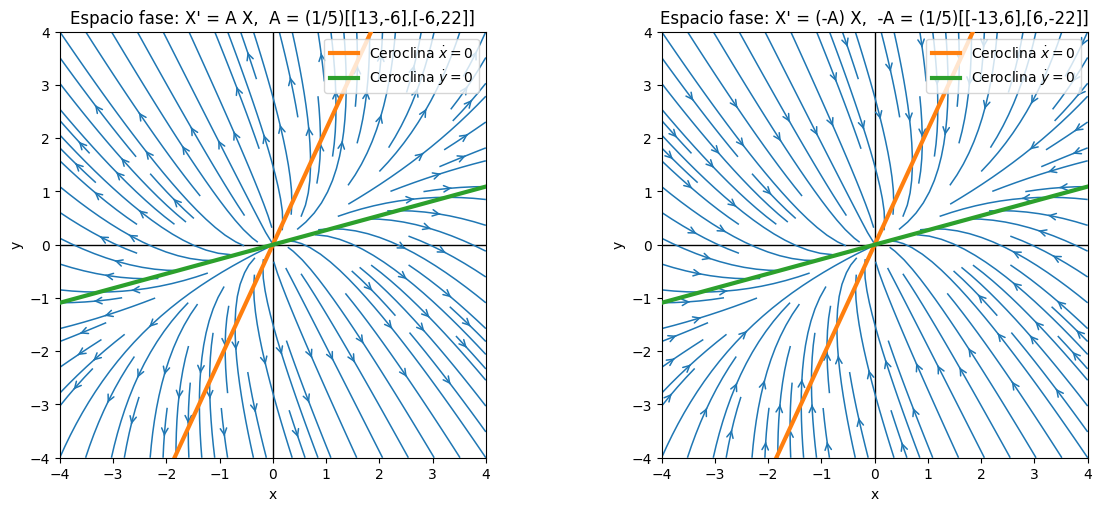

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_phase(ax, A, title, L=4, dens=1.1):
    # mallado
    x = np.linspace(-L, L, 320)
    y = np.linspace(-L, L, 320)
    X, Y = np.meshgrid(x, y)

    # campo: [x'; y'] = A [x; y]
    U = A[0,0]*X + A[0,1]*Y
    V = A[1,0]*X + A[1,1]*Y

    # retrato de fase
    ax.streamplot(
        x, y, U, V,
        density=dens,
        linewidth=1.1,
        arrowsize=1.15,
        arrowstyle='->',
        color='tab:blue',
        zorder=1
    )

    # ejes cartesianos
    ax.axhline(0, color='k', lw=1, zorder=0)
    ax.axvline(0, color='k', lw=1, zorder=0)

    # --- ceroclinas ---
    # xdot = 0  => a11 x + a12 y = 0
    # ydot = 0  => a21 x + a22 y = 0
    a11, a12 = A[0,0], A[0,1]
    a21, a22 = A[1,0], A[1,1]

    xx = np.linspace(-L, L, 500)

    # Ceroclina xdot=0 (naranja)
    if abs(a12) > 1e-12:
        yy = -(a11/a12) * xx
        ax.plot(xx, yy, color='tab:orange', lw=3, zorder=3)
    else:
        if abs(a11) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:orange', lw=3, zorder=3)

    # Ceroclina ydot=0 (verde)
    if abs(a22) > 1e-12:
        yy = -(a21/a22) * xx
        ax.plot(xx, yy, color='tab:green', lw=3, zorder=3)
    else:
        if abs(a21) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:green', lw=3, zorder=3)

    # leyenda
    handles = [
        Line2D([0],[0], color='tab:orange', lw=3, label=r'Ceroclina $\dot{x}=0$'),
        Line2D([0],[0], color='tab:green',  lw=3, label=r'Ceroclina $\dot{y}=0$')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=True)

    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)

# ---- Matrices de la imagen ----
A  = (1/5) * np.array([[ 13, -6],
                      [-6,  22]], dtype=float)

minusA = -A  # (1/5)*[[-13, 6],[6,-22]]

# ---- Figura con 2 imágenes ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_phase(axes[0], A,      "Espacio fase: X' = A X,  A = (1/5)[[13,-6],[-6,22]]", L=4, dens=1.15)
plot_phase(axes[1], minusA, "Espacio fase: X' = (-A) X,  -A = (1/5)[[-13,6],[6,-22]]", L=4, dens=1.15)


plt.show()


### $$\hookrightarrow \text{Si}\quad \det(A) > 0\quad y \quad (\operatorname{tr}(A))^2 - 4\det(A)=0$$
 
Esto nos diria que $\lambda _1 = \lambda _2\in\mathbb{R}$ 


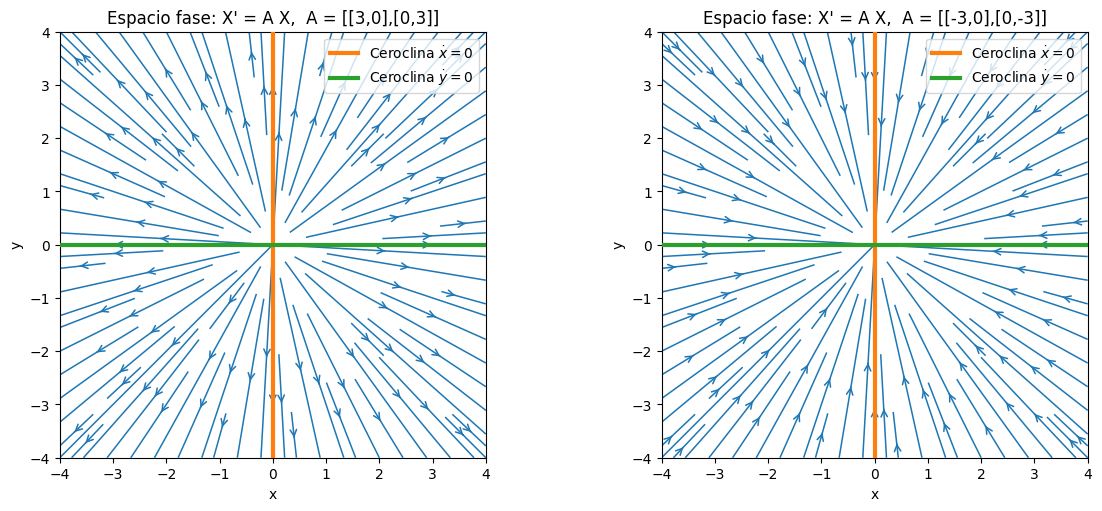

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_phase(ax, A, title, L=4, dens=1.2):
    x = np.linspace(-L, L, 320)
    y = np.linspace(-L, L, 320)
    X, Y = np.meshgrid(x, y)

    U = A[0,0]*X + A[0,1]*Y
    V = A[1,0]*X + A[1,1]*Y

    ax.streamplot(
        x, y, U, V,
        density=dens,
        linewidth=1.1,
        arrowsize=1.15,
        arrowstyle='->',
        color='tab:blue',
        zorder=1
    )

    # ejes cartesianos
    ax.axhline(0, color='k', lw=1, zorder=0)
    ax.axvline(0, color='k', lw=1, zorder=0)

    # ceroclinas: xdot=0 y ydot=0
    a11, a12 = A[0,0], A[0,1]
    a21, a22 = A[1,0], A[1,1]
    xx = np.linspace(-L, L, 500)

    # xdot=0 (naranja)
    if abs(a12) > 1e-12:
        ax.plot(xx, -(a11/a12)*xx, color='tab:orange', lw=3, zorder=3)
    else:
        # a11 x = 0  -> x=0 si a11!=0, o todo el plano si a11=0
        if abs(a11) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:orange', lw=3, zorder=3)

    # ydot=0 (verde)
    if abs(a22) > 1e-12:
        ax.plot(xx, -(a21/a22)*xx, color='tab:green', lw=3, zorder=3)
    else:
        if abs(a21) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:green', lw=3, zorder=3)

    # leyenda
    handles = [
        Line2D([0],[0], color='tab:orange', lw=3, label=r'Ceroclina $\dot{x}=0$'),
        Line2D([0],[0], color='tab:green',  lw=3, label=r'Ceroclina $\dot{y}=0$')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=True)

    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)

# ---- Matrices de la imagen ----
Aplus  = np.array([[ 3, 0],
                   [ 0, 3]], dtype=float)

Aminus = np.array([[-3, 0],
                   [ 0,-3]], dtype=float)

# ---- Figura con 2 imágenes ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_phase(axes[0], Aplus,  "Espacio fase: X' = A X,  A = [[3,0],[0,3]]",   L=4, dens=1.25)
plot_phase(axes[1], Aminus, "Espacio fase: X' = A X,  A = [[-3,0],[0,-3]]", L=4, dens=1.25)

plt.show()


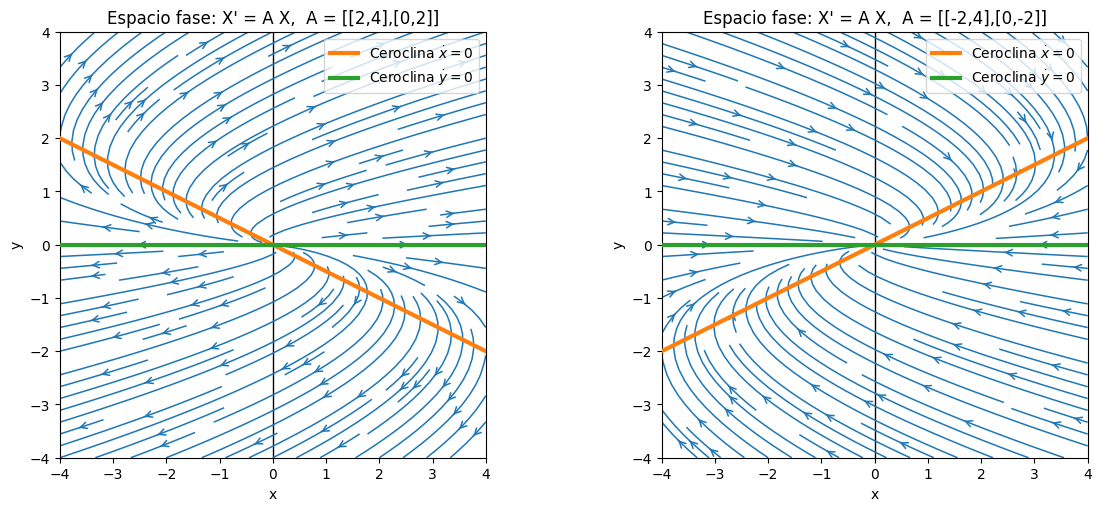

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_phase(ax, A, title, L=4, dens=1.2):
    x = np.linspace(-L, L, 350)
    y = np.linspace(-L, L, 350)
    X, Y = np.meshgrid(x, y)

    # Campo: [x'; y'] = A [x; y]
    U = A[0,0]*X + A[0,1]*Y
    V = A[1,0]*X + A[1,1]*Y

    ax.streamplot(
        x, y, U, V,
        density=dens,
        linewidth=1.1,
        arrowsize=1.15,
        arrowstyle='->',
        color='tab:blue',
        zorder=1
    )

    # ejes
    ax.axhline(0, color='k', lw=1, zorder=0)
    ax.axvline(0, color='k', lw=1, zorder=0)

    # Ceroclinas: xdot=0 y ydot=0
    a11, a12 = A[0,0], A[0,1]
    a21, a22 = A[1,0], A[1,1]
    xx = np.linspace(-L, L, 600)

    # xdot=0 (naranja): a11 x + a12 y = 0
    if abs(a12) > 1e-12:
        ax.plot(xx, -(a11/a12)*xx, color='tab:orange', lw=3, zorder=3)
    else:
        if abs(a11) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:orange', lw=3, zorder=3)

    # ydot=0 (verde): a21 x + a22 y = 0
    if abs(a22) > 1e-12:
        ax.plot(xx, -(a21/a22)*xx, color='tab:green', lw=3, zorder=3)
    else:
        if abs(a21) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:green', lw=3, zorder=3)

    handles = [
        Line2D([0],[0], color='tab:orange', lw=3, label=r'Ceroclina $\dot{x}=0$'),
        Line2D([0],[0], color='tab:green',  lw=3, label=r'Ceroclina $\dot{y}=0$')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=True)

    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)

# ====== valores pedidos ======
k = 4.0

Apos = np.array([[ 2, k],
                 [ 0, 2]], dtype=float)

Aneg = np.array([[-2, k],
                 [ 0,-2]], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_phase(axes[0], Apos, "Espacio fase: X' = A X,  A = [[2,4],[0,2]]",    L=4, dens=1.25)
plot_phase(axes[1], Aneg, "Espacio fase: X' = A X,  A = [[-2,4],[0,-2]]",  L=4, dens=1.25)

plt.show()


### $$\hookrightarrow \text{Si}\quad \det(A) > 0\quad y \quad (\operatorname{tr}(A))^2 - 4\det(A)<0$$
 
Esto nos diria que $\lambda _1 = \overline{\lambda _2}\in\mathbb{C}$ 


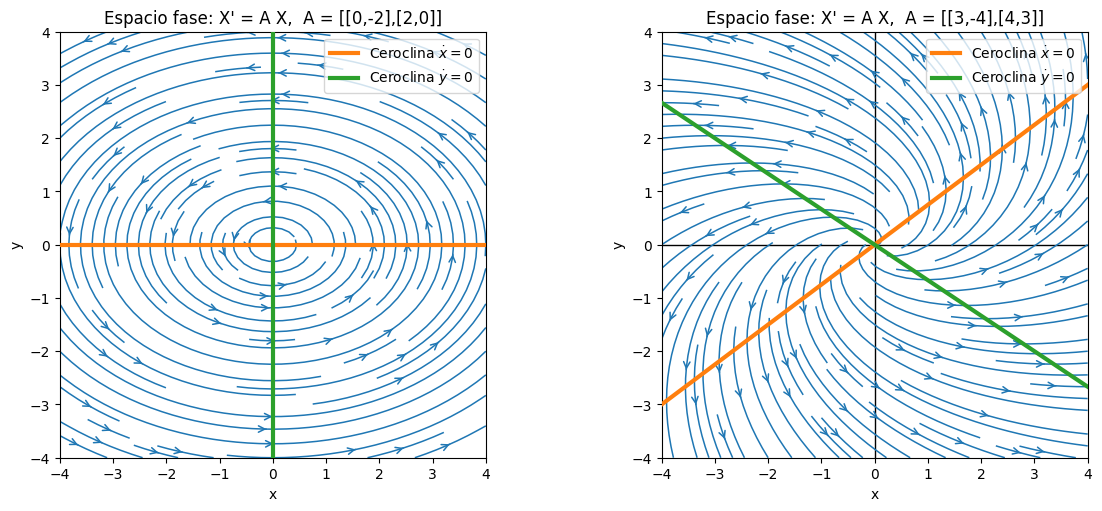

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_phase(ax, A, title, L=4, dens=1.2):
    x = np.linspace(-L, L, 350)
    y = np.linspace(-L, L, 350)
    X, Y = np.meshgrid(x, y)

    # Campo: [x'; y'] = A [x; y]
    U = A[0,0]*X + A[0,1]*Y
    V = A[1,0]*X + A[1,1]*Y

    ax.streamplot(
        x, y, U, V,
        density=dens,
        linewidth=1.1,
        arrowsize=1.15,
        arrowstyle='->',
        color='tab:blue',
        zorder=1
    )

    # ejes
    ax.axhline(0, color='k', lw=1, zorder=0)
    ax.axvline(0, color='k', lw=1, zorder=0)

    # Ceroclinas: xdot=0 y ydot=0
    a11, a12 = A[0,0], A[0,1]
    a21, a22 = A[1,0], A[1,1]
    xx = np.linspace(-L, L, 600)

    # xdot=0 (naranja): a11 x + a12 y = 0
    if abs(a12) > 1e-12:
        ax.plot(xx, -(a11/a12)*xx, color='tab:orange', lw=3, zorder=3)
    else:
        if abs(a11) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:orange', lw=3, zorder=3)
        # si a11=0 y a12=0 => xdot=0 en todo el plano (no se dibuja)

    # ydot=0 (verde): a21 x + a22 y = 0
    if abs(a22) > 1e-12:
        ax.plot(xx, -(a21/a22)*xx, color='tab:green', lw=3, zorder=3)
    else:
        if abs(a21) > 1e-12:
            ax.plot([0, 0], [-L, L], color='tab:green', lw=3, zorder=3)
        # si a21=0 y a22=0 => ydot=0 en todo el plano (no se dibuja)

    handles = [
        Line2D([0],[0], color='tab:orange', lw=3, label=r'Ceroclina $\dot{x}=0$'),
        Line2D([0],[0], color='tab:green',  lw=3, label=r'Ceroclina $\dot{y}=0$')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=True)

    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)

# ---- Matrices de tu foto ----
A1 = np.array([[0, -4],
               [2,  0]], dtype=float)

A2 = np.array([[ 3, -4],
               [ 2,  3]], dtype=float)

# ---- Figura con 2 imágenes ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_phase(axes[0], A1, "Espacio fase: X' = A X,  A = [[0,-2],[2,0]]",   L=4, dens=1.25)
plot_phase(axes[1], A2, "Espacio fase: X' = A X,  A = [[3,-4],[4,3]]",   L=4, dens=1.25)

plt.show()


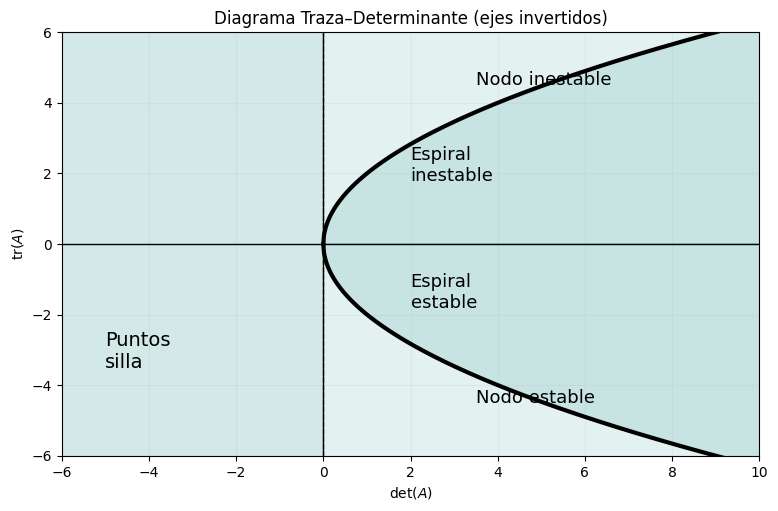

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Rangos
det_min, det_max = -6, 10
tau_min, tau_max = -6, 6

# Mallado
D = np.linspace(det_min, det_max, 600)   # det(A)
T = np.linspace(tau_min, tau_max, 600)   # tr(A)
DD, TT = np.meshgrid(D, T)

# Discriminante
disc = TT**2 - 4*DD

# Regiones
saddle = (DD < 0)

stable = (DD > 0) & (TT < 0)
unstable = (DD > 0) & (TT > 0)

real_eigs = (disc >= 0)
complex_eigs = (disc < 0)

stable_node   = stable & real_eigs
stable_spiral = stable & complex_eigs

unstable_node   = unstable & real_eigs
unstable_spiral = unstable & complex_eigs

# Figura
fig, ax = plt.subplots(figsize=(9, 5.5))

# Sombreado
ax.contourf(DD, TT, saddle, levels=[0.5, 1.5], alpha=0.20)
ax.contourf(DD, TT, stable_spiral, levels=[0.5, 1.5], alpha=0.25)
ax.contourf(DD, TT, stable_node, levels=[0.5, 1.5], alpha=0.12)
ax.contourf(DD, TT, unstable_spiral, levels=[0.5, 1.5], alpha=0.25)
ax.contourf(DD, TT, unstable_node, levels=[0.5, 1.5], alpha=0.12)

# Ejes
ax.axhline(0, color='k', lw=1)
ax.axvline(0, color='k', lw=1)

# Curva discriminante: tau = ±2 sqrt(det)
det_curve = np.linspace(0, det_max, 800)
tau_curve = 2 * np.sqrt(det_curve)

ax.plot(det_curve,  tau_curve, color='k', lw=3)
ax.plot(det_curve, -tau_curve, color='k', lw=3)

# Línea det = 0
ax.axvline(0, color='k', lw=1, linestyle='--', alpha=0.7)

# Etiquetas
ax.text(-5, -3.5, "Puntos\nsilla", fontsize=14)
ax.text( 3.5, -4.5, "Nodo estable", fontsize=13)
ax.text( 2.0, -1.8, "Espiral\nestable", fontsize=13)

ax.text( 3.5,  4.5, "Nodo inestable", fontsize=13)
ax.text( 2.0,  1.8, "Espiral\ninestable", fontsize=13)

# Formato
ax.set_xlim(det_min, det_max)
ax.set_ylim(tau_min, tau_max)
ax.set_xlabel(r"$\det(A)$")
ax.set_ylabel(r"$\mathrm{tr}(A)$")
ax.set_title("Diagrama Traza–Determinante (ejes invertidos)")
ax.grid(alpha=0.15)

plt.show()
